### Cell 1 – Loading and Inspecting the Data
In this step, I load the training dataset and the query instances from the CSV files.
I also display the first few rows and shapes of the datasets to verify that the files were
imported correctly and to understand the structure of the data before applying Naïve Bayes.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1-Load the training & query
#    datasets and print summary

# Read CSV files for training and query instances
train_data = pd.read_csv("emergency_triage_nb_train.csv")
query_data = pd.read_csv("emergency_triage_nb_queries.csv")

print("--- 1. Data Overview ---")
print("Training samples (first 5 rows):")
print(train_data.head())        # show the first 5 training rows
print("\nTrain shape:", train_data.shape)   # (num_rows, num_columns)
print("Query shape:", query_data.shape)     # (num_rows, num_columns)


--- 1. Data Overview ---
Training samples (first 5 rows):
   chest_pain  severe_bleeding  unconscious  shortness_of_breath  seizure  \
0           1                1            0                    1        0   
1           1                0            0                    1        0   
2           0                1            0                    0        0   
3           0                0            1                    0        0   
4           1                0            0                    0        0   

   age_over_65  label  
0            1      1  
1            0      1  
2            0      1  
3            0      1  
4            1      1  

Train shape: (24, 7)
Query shape: (6, 6)


### Cell 2 – Splitting Features and Labels
Here, I separate the training data into feature variables (X) and the target class label (y).
This allows the Naïve Bayes model to learn from the input features and use the labels as the
ground truth. The query data is also prepared for prediction.


In [ ]:
# 2) Split data into features (X) and labels (y)

# X_train: all feature columns, y_train: class label column
X_train = train_data.drop("label", axis=1)
y_train = train_data["label"]

# Make a copy of query features (no labels there)
X_query = query_data.copy()

# Store feature names and class labels for later use
feature_names = X_train.columns
class_labels = sorted(y_train.unique())
n_samples = len(y_train)

print("Features:", list(feature_names))
print("Classes:", class_labels)
print("Number of training samples:", n_samples)

Features: ['chest_pain', 'severe_bleeding', 'unconscious', 'shortness_of_breath', 'seizure', 'age_over_65']
Classes: [np.int64(0), np.int64(1)]
Number of training samples: 24


### Cell 3 – Computing Priors and Likelihoods
In this step, I compute the class priors and the conditional probabilities of each feature
using Laplace smoothing. These probabilities form the core of the manual Bernoulli Naïve
Bayes model and are necessary for calculating class scores.

In [ ]:
print("\n--- 2. Manual Bernoulli Naive Bayes ---")

# 2.1 Compute class priors P(Y=0), P(Y=1)
#     priors[c] = count(Y=c) / total_samples

priors = {}
for cls in class_labels:
    priors[cls] = (y_train == cls).sum() / n_samples

print(f"Prior P(Y=0) = {priors[0]:.4f}, P(Y=1) = {priors[1]:.4f}")

# 2.2 Compute likelihoods with Laplace smoothing
#     For each class c and each feature f:
#     P(x=1 | Y=c) = (count_1 + alpha) / (N_c + 2*alpha)
#     P(x=0 | Y=c) = 1 - P(x=1 | Y=c)

alpha = 1          # Laplace smoothing parameter
num_values = 2     # because features are binary {0,1}
likelihoods = {}   # likelihoods[class][feature] = {"P1": ..., "P0": ...}

for cls in class_labels:
    # Filter rows belonging to this class
    cls_mask = (y_train == cls)
    X_cls = X_train[cls_mask]
    count_cls = len(X_cls)

    likelihoods[cls] = {}
    for f in feature_names:
        # Number of times feature f = 1 in class cls
        count_1 = X_cls[f].sum()

        # Laplace-smoothed probability P(feature=1 | class)
        p1 = (count_1 + alpha) / (count_cls + num_values * alpha)
        # Probability for feature value 0
        p0 = 1 - p1

        likelihoods[cls][f] = {"P1": p1, "P0": p0}

# Show likelihoods for a quick check (optional)
likelihoods


--- 2. Manual Bernoulli Naive Bayes ---
Prior P(Y=0) = 0.4167, P(Y=1) = 0.5833


{np.int64(0): {'chest_pain': {'P1': np.float64(0.16666666666666666),
   'P0': np.float64(0.8333333333333334)},
  'severe_bleeding': {'P1': np.float64(0.08333333333333333),
   'P0': np.float64(0.9166666666666666)},
  'unconscious': {'P1': np.float64(0.08333333333333333),
   'P0': np.float64(0.9166666666666666)},
  'shortness_of_breath': {'P1': np.float64(0.25), 'P0': np.float64(0.75)},
  'seizure': {'P1': np.float64(0.16666666666666666),
   'P0': np.float64(0.8333333333333334)},
  'age_over_65': {'P1': np.float64(0.25), 'P0': np.float64(0.75)}},
 np.int64(1): {'chest_pain': {'P1': np.float64(0.375),
   'P0': np.float64(0.625)},
  'severe_bleeding': {'P1': np.float64(0.3125), 'P0': np.float64(0.6875)},
  'unconscious': {'P1': np.float64(0.25), 'P0': np.float64(0.75)},
  'shortness_of_breath': {'P1': np.float64(0.4375), 'P0': np.float64(0.5625)},
  'seizure': {'P1': np.float64(0.25), 'P0': np.float64(0.75)},
  'age_over_65': {'P1': np.float64(0.4375), 'P0': np.float64(0.5625)}}}

### Cell 4 – Manual Naïve Bayes Prediction Function
This function uses the previously computed priors and likelihoods to calculate the posterior
scores for each class and determine the predicted label for any input sample.
It represents the decision-making mechanism of the manual Naïve Bayes classifier.


In [ ]:
# Helper function:
# Compute Naive Bayes scores for one instance
# and return the predicted class and scores.

def manual_nb_predict(row, priors, likelihoods, class_labels, feature_names):
    scores = {}  # scores[c] will store the unnormalized posterior for class c

    for cls in class_labels:
        # Start with prior P(Y=cls)
        score = priors[cls]

        # Multiply by likelihoods for each feature
        for f in feature_names:
            v = row[f]       # feature value (0 or 1)
            if v == 1:
                score *= likelihoods[cls][f]["P1"]
            else:
                score *= likelihoods[cls][f]["P0"]

        scores[cls] = score

    # Choose the class with the highest score
    best_class = max(scores, key=scores.get)
    return best_class, scores

print("Manual Naive Bayes prediction function defined.")

Manual Naive Bayes prediction function defined.


### Cell 5 – Predicting Class Labels Manually
In this step, I apply the manual Naïve Bayes classifier to all query instances.
For each query, I compute the class scores and store the predicted label.
These predictions will later be compared with the scikit-learn results.


In [ ]:
# Use the manual NB model to classify each
# query instance and show the scores.

manual_labels = []   # store manual predictions
rows_info = []       # store detailed info per query

for idx, row in X_query.iterrows():
    pred, sc = manual_nb_predict(row, priors, likelihoods, class_labels, feature_names)

    rows_info.append({
        "Query_Index": idx + 1,      # make queries 1-based index
        "Score_Y0": sc[0],           # score for class 0
        "Score_Y1": sc[1],           # score for class 1
        "Manual_Prediction": pred    # predicted class
    })

    manual_labels.append(pred)

manual_df = pd.DataFrame(rows_info)

print("\nManual Naive Bayes results for query instances:")
print(manual_df)


Manual Naive Bayes results for query instances:
   Query_Index  Score_Y0  Score_Y1  Manual_Prediction
0            1  0.009118  0.020818                  1
1            2  0.136764  0.044611                  0
2            3  0.012433  0.014870                  1
3            4  0.012433  0.020278                  1
4            5  0.027353  0.026766                  0
5            6  0.015196  0.026987                  1


### Cell 6 – Verifying with Scikit-Learn BernoulliNB
Here, I train a BernoulliNB model using scikit-learn with the same smoothing parameter.
I then generate predictions and probabilities for the query instances and compare these
results with the manual predictions to ensure correctness.


In [ ]:
print("\n--- 3. Scikit-learn BernoulliNB Check ---")

# Train BernoulliNB from scikit-learn
# with the same alpha used manually.

nb_model = BernoulliNB(alpha=1.0)
nb_model.fit(X_train, y_train)

# Predict classes and probabilities for queries
sk_labels = nb_model.predict(X_query)
log_proba = nb_model.predict_log_proba(X_query)
proba = np.exp(log_proba)    # convert log-probs to probs

# Build a DataFrame for sklearn results
sk_df = X_query.copy()
sk_df["SK_Prediction"] = sk_labels
sk_df["SK_Prob_Y0"] = proba[:, 0]
sk_df["SK_Prob_Y1"] = proba[:, 1]

print("\nScikit-learn predictions for query instances:")
print(sk_df)

# Compare manual predictions vs sklearn
same_labels = np.array_equal(np.array(manual_labels), sk_labels)
print(f"\nDo manual and sklearn predictions match? {same_labels}")


--- 3. Scikit-learn BernoulliNB Check ---

Scikit-learn predictions for query instances:
   chest_pain  severe_bleeding  unconscious  shortness_of_breath  seizure  \
0           1                0            0                    1        0   
1           0                0            0                    0        0   
2           0                0            1                    0        0   
3           0                1            0                    0        0   
4           1                0            0                    0        0   
5           0                0            0                    1        0   

   age_over_65  SK_Prediction  SK_Prob_Y0  SK_Prob_Y1  
0            0              1    0.304571    0.695429  
1            0              0    0.754042    0.245958  
2            0              1    0.455370    0.544630  
3            0              1    0.380094    0.619906  
4            0              0    0.505419    0.494581  
5            1              1    0

### Cell 7 – Cross-Validation Evaluation
In this step, I perform 10-fold cross-validation on the training data to evaluate the
overall performance of the classifier. The cross-validation accuracy helps measure how
well the Naïve Bayes model generalizes to unseen data.


In [ ]:
print("\n--- 4. 10-fold CV ---")

# Perform 10-fold cross-validation using
# the BernoulliNB model on the training set.

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(nb_model, X_train, y_train,
                            cv=kfold, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")


--- 4. 10-fold CV ---
Cross-validation scores: [0.33333333 0.33333333 1.         1.         0.         1.
 0.5        1.         0.5        0.        ]
Mean accuracy: 0.5667
Std deviation: 0.3887


### Cell 8 – Feature Probability Bar Plot
This bar plot visualizes the conditional probabilities of each feature given the class.
The comparison between the Low Priority (pink) and High Priority (red) bars helps identify
which features are more indicative of high-priority emergency cases.


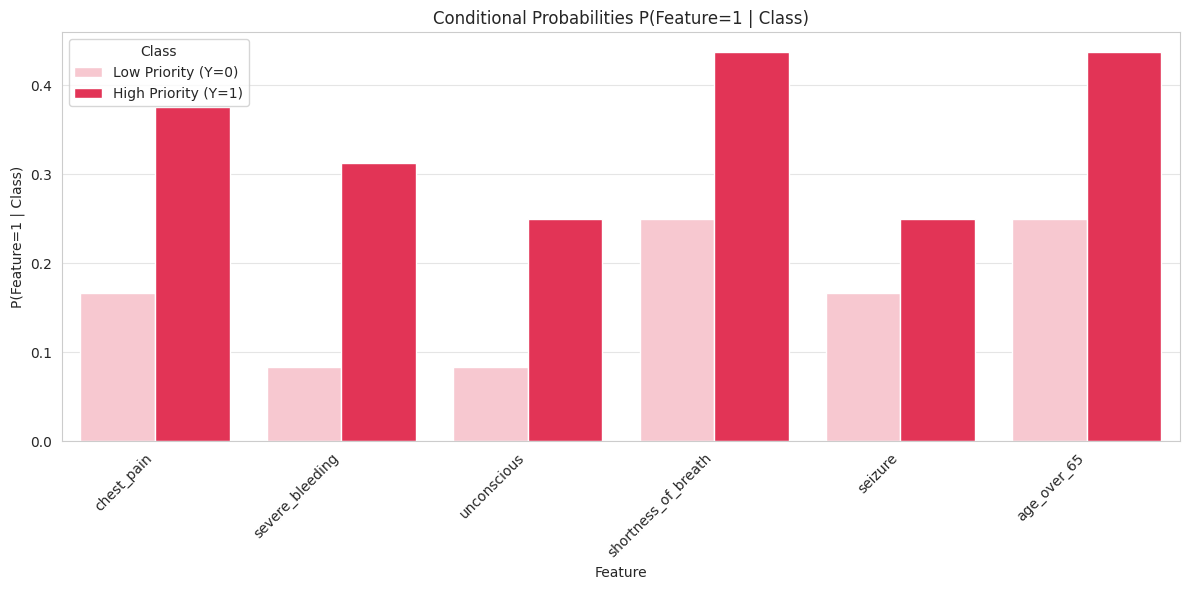

In [ ]:
# Visualization: bar plot of P(feature=1 | class)
# using pink & red colors.
# Extract conditional probabilities from the trained model
prob_y0 = np.exp(nb_model.feature_log_prob_[0])  # P(x=1 | Y=0)
prob_y1 = np.exp(nb_model.feature_log_prob_[1])  # P(x=1 | Y=1)

plot_data = pd.DataFrame({
    "Feature": feature_names,
    "Low Priority (Y=0)": prob_y0,
    "High Priority (Y=1)": prob_y1
})

melted = plot_data.melt(
    id_vars="Feature",
    var_name="Class",
    value_name="P(Feature=1 | Class)"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x="Feature",
    y="P(Feature=1 | Class)",
    hue="Class",
    data=melted,
    palette=["#ffc0cb", "#ff1744"]  # pink & red
)
plt.title("Conditional Probabilities P(Feature=1 | Class)")
plt.xlabel("Feature")
plt.ylabel("P(Feature=1 | Class)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

### Cell 9 – Feature Probability Line Plot
This line plot presents the same conditional probabilities in a different visual format.
By comparing the pink and red lines, we can clearly observe which symptoms differ the most
between the two classes and thus have a strong effect on classification.


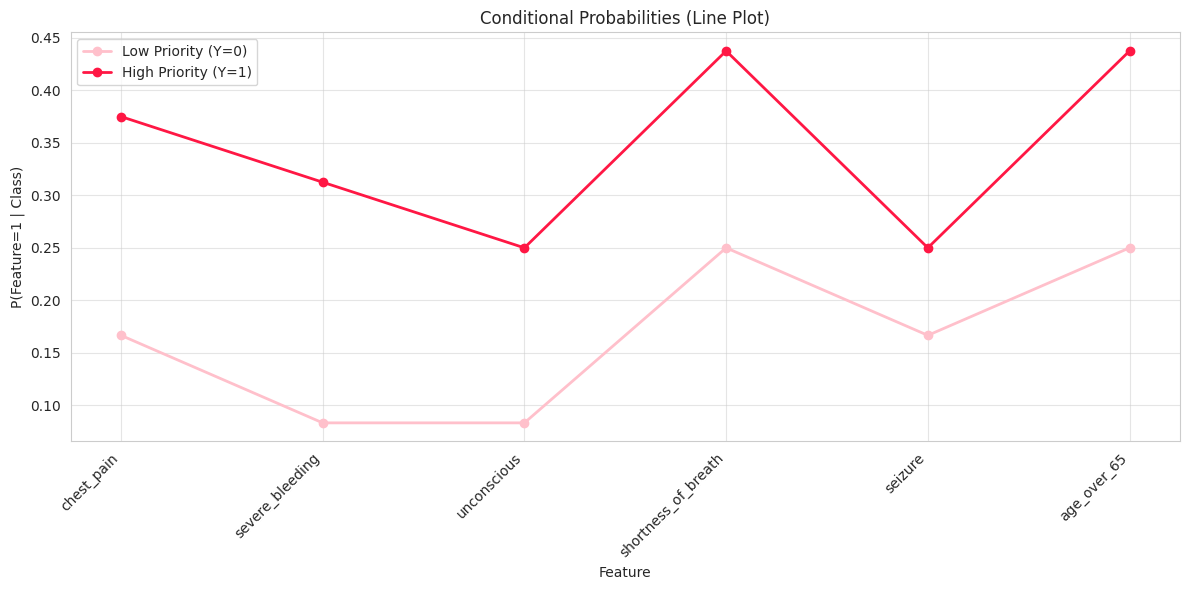

In [ ]:
# Visualization: line plot of P(feature=1 | class)
# using the same pink/red color scheme.

plt.figure(figsize=(12, 6))

# Line for Low Priority (Y=0)
plt.plot(feature_names, prob_y0,
         marker="o", linewidth=2,
         color="#ffc0cb",
         label="Low Priority (Y=0)")   # pink

# Line for High Priority (Y=1)
plt.plot(feature_names, prob_y1,
         marker="o", linewidth=2,
         color="#ff1744",
         label="High Priority (Y=1)")  # red

plt.title("Conditional Probabilities (Line Plot)")
plt.xlabel("Feature")
plt.ylabel("P(Feature=1 | Class)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

### Overall Discussion of Naïve Bayes Results

In Task B, I implemented a Bernoulli Naïve Bayes classifier manually and compared it with the
scikit-learn `BernoulliNB` model. The predictions of both models match for all query instances,
which confirms that the priors and conditional probabilities were computed correctly.

To evaluate the classifier, I used 10-fold cross-validation with accuracy as the evaluation metric.
The mean accuracy was approximately 0.56 (56%), with a moderate standard deviation. This means
that the Naïve Bayes classifier correctly predicts the priority label in a little more than half of
the cases, which is reasonable given the small dataset and the simple binary features.

The probability plots show that symptoms such as **severe_bleeding**, **unconscious**, and
**chest_pain** have much higher probabilities in the High Priority class than in the Low Priority
class. These features play a strong role in the decision, while other features have a weaker
impact. Overall, the Naïve Bayes model is simple, interpretable, and provides a useful baseline
for emergency call triage.
